Import, Dataset Loading & Preprocessing

In [ ]:
!pip -q install kagglehub

Import Libraries

In [ ]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

warnings.filterwarnings("ignore")

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


Set Seed

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Hyperparameters

In [ ]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 20

LEARNING_RATE = 1e-4

Download Dataset

In [ ]:
dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


Dataset Paths

In [ ]:
dataset_path = os.path.join(dataset_path,"chest_xray")

train_dir = os.path.join(dataset_path,"train")

test_dir = os.path.join(dataset_path,"test")

print(train_dir)

print(test_dir)

/kaggle/input/chest-xray-pneumonia/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/test


Load Dataset

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    validation_split=0.20,

    subset="training",

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)

val_ds = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    validation_split=0.20,

    subset="validation",

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)

test_ds = tf.keras.utils.image_dataset_from_directory(

    test_dir,

    shuffle=False,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE

)

CLASS_NAMES = train_ds.class_names

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


Check Class Names

In [ ]:
print(train_ds.class_names)

['NORMAL', 'PNEUMONIA']


Optimize Dataset Pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

normalization = layers.Rescaling(1./255)

train_ds = train_ds.map(

    lambda x,y:(normalization(x),y),

    num_parallel_calls=AUTOTUNE

)

val_ds = val_ds.map(

    lambda x,y:(normalization(x),y),

    num_parallel_calls=AUTOTUNE

)

test_ds = test_ds.map(

    lambda x,y:(normalization(x),y),

    num_parallel_calls=AUTOTUNE

)

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

Display Sample Images

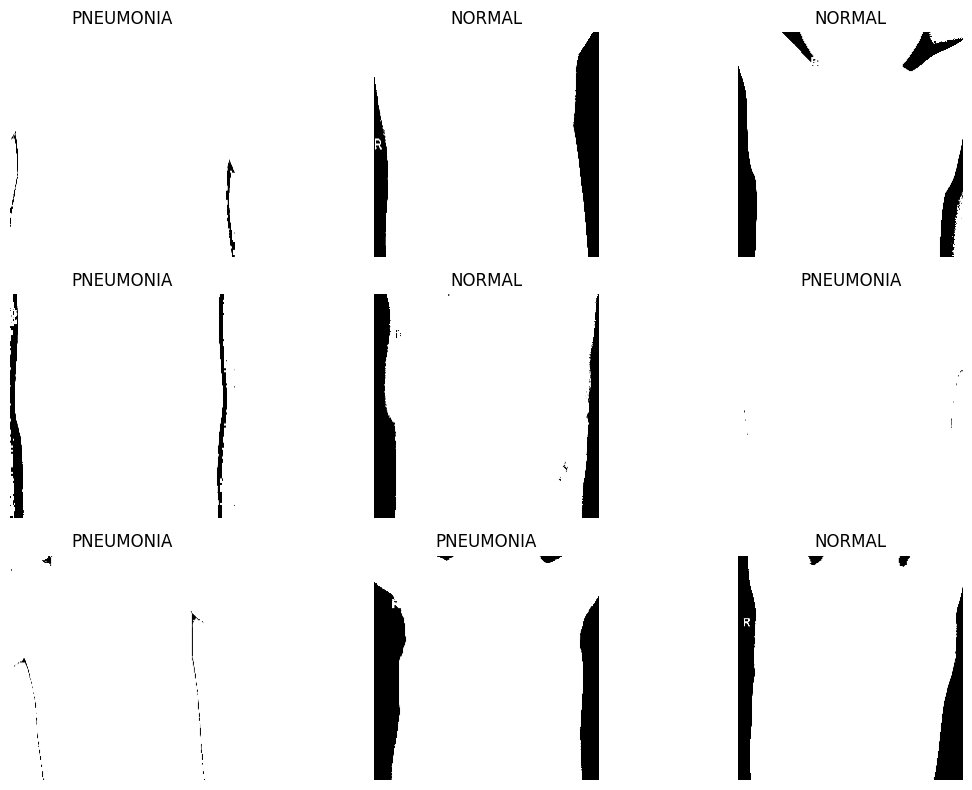

In [ ]:
plt.figure(figsize=(12,8))

for images,labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype(np.float32), vmin=0, vmax=1)

        plt.title(CLASS_NAMES[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()

Calculate Class Weights

In [ ]:
labels=[]

for _,y in train_ds.unbatch():

    labels.append(int(y.numpy()))

weights = compute_class_weight(

    class_weight="balanced",

    classes=np.unique(labels),

    y=labels

)

class_weights={

    0:weights[0],

    1:weights[1]

}

print(class_weights)

{0: np.float64(1.9107142857142858), 1: np.float64(0.6772151898734177)}


Clear Previous Models

In [ ]:
import gc

tf.keras.backend.clear_session()

gc.collect()

0

Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.10),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10)

], name="data_augmentation")

Build CNN Model

In [ ]:
model = models.Sequential([

    ###################################################
    # Input Layer
    ###################################################

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    ###################################################
    # Block 1
    ###################################################

    layers.Conv2D(
        32,
        (3,3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        32,
        (3,3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),

    ###################################################
    # Block 2
    ###################################################

    layers.Conv2D(
        64,
        (3,3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3,3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.30),

    ###################################################
    # Block 3
    ###################################################

    layers.Conv2D(
        128,
        (3,3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        128,
        (3,3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.30),

    ###################################################
    # Block 4
    ###################################################

    layers.Conv2D(
        256,
        (3,3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        256,
        (3,3),
        padding="same",
        activation="relu"
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.40),

    ###################################################
    # Classifier
    ###################################################

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.50),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.30),

    layers.Dense(
        1,
        activation="sigmoid"
    )

])

Display Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,274,913 (4.86 MB)

 Trainable params: 1,272,993 (4.86 MB)

 Non-trainable params: 1,920 (7.50 KB)

Compile the Model

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall"),

        tf.keras.metrics.AUC(name="auc")

    ]

)

Verify Model

In [ ]:
print(model.input_shape)

print(model.output_shape)

(None, 224, 224, 3)
(None, 1)


Count Trainable Parameters

In [ ]:
print("Trainable Parameters:")

print(

    np.sum(

        [tf.keras.backend.count_params(w)

         for w in model.trainable_weights]

    )

)

Trainable Parameters:
1272993


Save Model Architecture

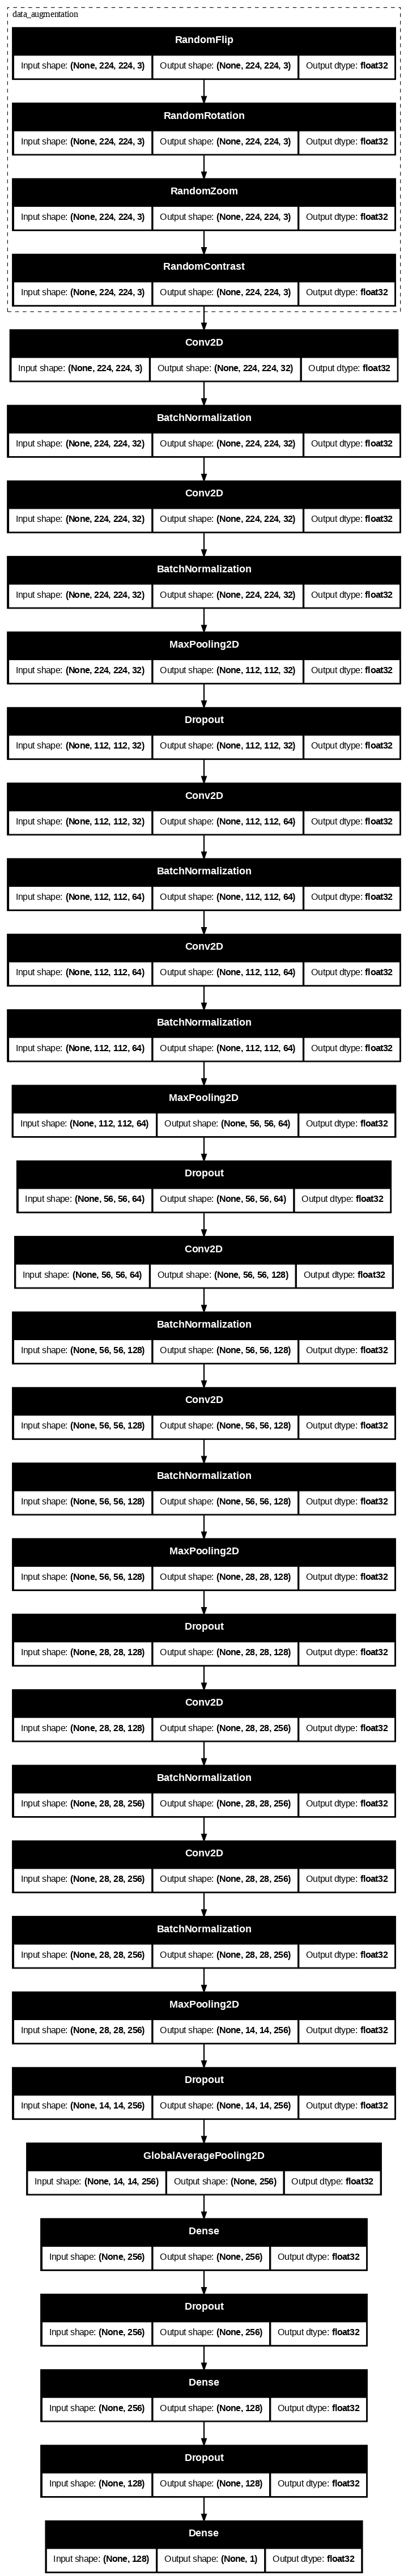

In [ ]:
tf.keras.utils.plot_model(

    model,

    show_shapes=True,

    show_dtype=True,

    expand_nested=True,

    dpi=80
)

Remove Previous Saved Model

In [ ]:
import os

if os.path.exists("best_cnn.keras"):
    os.remove("best_cnn.keras")
    print("Previous model deleted.")
else:
    print("No previous model found.")

No previous model found.


Create Callbacks

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint = ModelCheckpoint(

    filepath="best_cnn.keras",

    monitor="val_loss",

    mode="min",

    save_best_only=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1

)

callbacks = [

    checkpoint,

    reduce_lr,

    early_stop

]

Start Training

In [ ]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7060 - auc: 0.8044 - loss: 0.5153 - precision: 0.8950 - recall: 0.6668
Epoch 1: val_loss improved from None to 0.30881, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 465ms/step - accuracy: 0.8069 - auc: 0.8974 - loss: 0.3973 - precision: 0.9505 - recall: 0.7790 - val_accuracy: 0.8792 - val_auc: 0.9459 - val_loss: 0.3088 - val_precision: 0.9338 - val_recall: 0.9055 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8864 - auc: 0.9499 - loss: 0.2699 - precision: 0.9796 - recall: 0.8631
Epoch 2: val_loss did not improve from 0.30881
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 405ms/step - accuracy: 0.8847 - auc: 0.9498 - loss: 0.2741 - precision: 0.9765 - recall: 0.8647 - val_accuracy: 0.6606 - val_auc: 0.9539 - val_loss: 0.7852 - val_precision: 0.9977 - val_recall: 0.5554 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━

Save Final Model

In [ ]:
model.save("custom_cnn_final.keras")

print("Model Saved Successfully")

Model Saved Successfully


Load Best Model

In [ ]:
best_model = tf.keras.models.load_model("best_cnn.keras")

Evaluate Best Model

In [ ]:
loss, accuracy, precision, recall, auc = best_model.evaluate(test_ds)

print("\nTest Accuracy :", accuracy)

print("Test Precision :", precision)

print("Test Recall :", recall)

print("Test AUC :", auc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.8013 - auc: 0.9053 - loss: 0.8393 - precision: 0.7639 - recall: 0.9872

Test Accuracy : 0.8012820482254028
Test Precision : 0.7638888955116272
Test Recall : 0.9871794581413269
Test AUC : 0.9052541851997375


Display Training History Keys

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])


Print Best Validation Accuracy

In [ ]:
best_epoch = np.argmax(history.history["val_accuracy"])

print("Best Epoch :", best_epoch + 1)

print("Best Validation Accuracy :",

      history.history["val_accuracy"][best_epoch])

Best Epoch : 9
Best Validation Accuracy : 0.9645254015922546


Print Lowest Validation Loss

In [ ]:
best_loss = np.argmin(history.history["val_loss"])

print("Lowest Validation Loss :",

      history.history["val_loss"][best_loss])

Lowest Validation Loss : 0.10665255784988403


Check Saved Files

In [ ]:
import os

print(os.listdir())

['.config', 'model.png', 'custom_cnn_final.keras', 'best_cnn.keras', 'sample_data']


Accuracy Graph

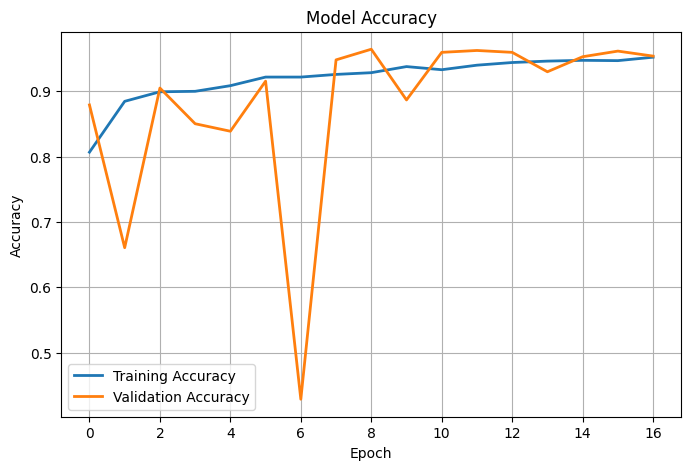

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy',
         linewidth=2)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.show()

Loss Graph

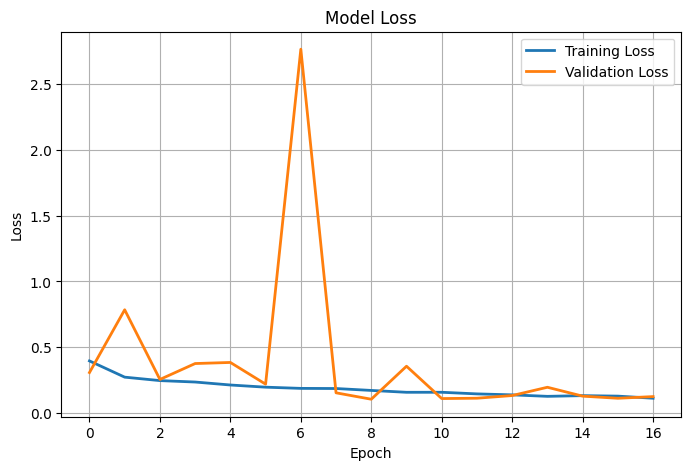

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.show()

Precision Graph

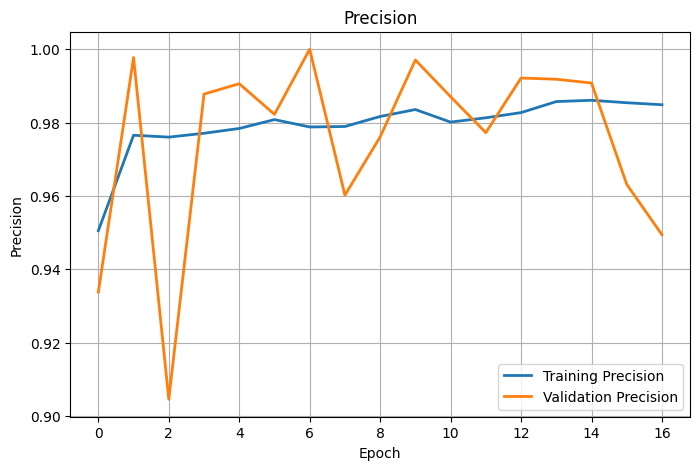

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['precision'],
         label='Training Precision',
         linewidth=2)

plt.plot(history.history['val_precision'],
         label='Validation Precision',
         linewidth=2)

plt.title("Precision")

plt.xlabel("Epoch")

plt.ylabel("Precision")

plt.grid(True)

plt.legend()

plt.show()

Recall Graph

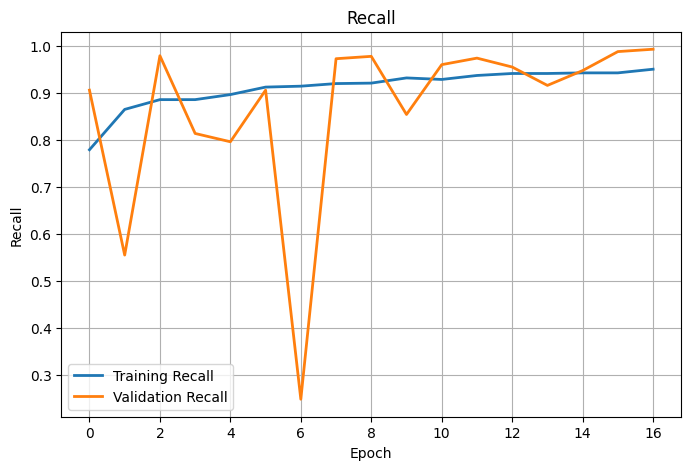

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['recall'],
         label='Training Recall',
         linewidth=2)

plt.plot(history.history['val_recall'],
         label='Validation Recall',
         linewidth=2)

plt.title("Recall")

plt.xlabel("Epoch")

plt.ylabel("Recall")

plt.grid(True)

plt.legend()

plt.show()

AUC Graph

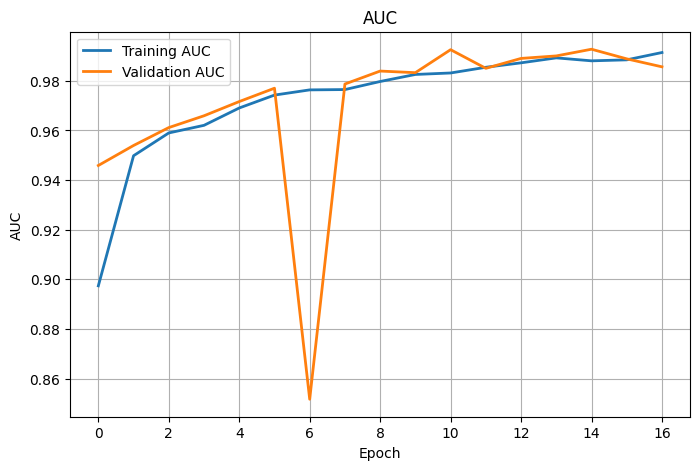

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['auc'],
         label='Training AUC',
         linewidth=2)

plt.plot(history.history['val_auc'],
         label='Validation AUC',
         linewidth=2)

plt.title("AUC")

plt.xlabel("Epoch")

plt.ylabel("AUC")

plt.grid(True)

plt.legend()

plt.show()

Predict Test Dataset

In [ ]:
import numpy as np

y_true = np.concatenate(
    [labels.numpy() for images, labels in test_ds]
)

y_prob = best_model.predict(test_ds)

y_pred = (y_prob > 0.5).astype(int).flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(

    y_true,

    y_pred,

    target_names=[
        "NORMAL",
        "PNEUMONIA"
    ]

))

              precision    recall  f1-score   support

      NORMAL       0.96      0.49      0.65       234
   PNEUMONIA       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.74      0.76       624
weighted avg       0.84      0.80      0.78       624



Confusion Matrix

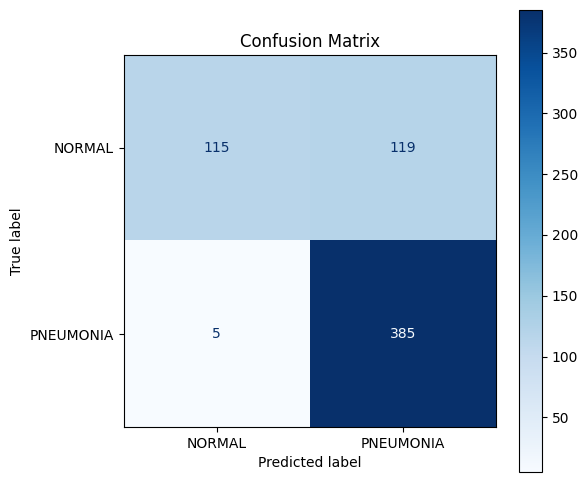

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "NORMAL",
        "PNEUMONIA"
    ]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(

    cmap="Blues",

    values_format="d",

    ax=ax

)

plt.title("Confusion Matrix")

plt.show()

ROC Curve

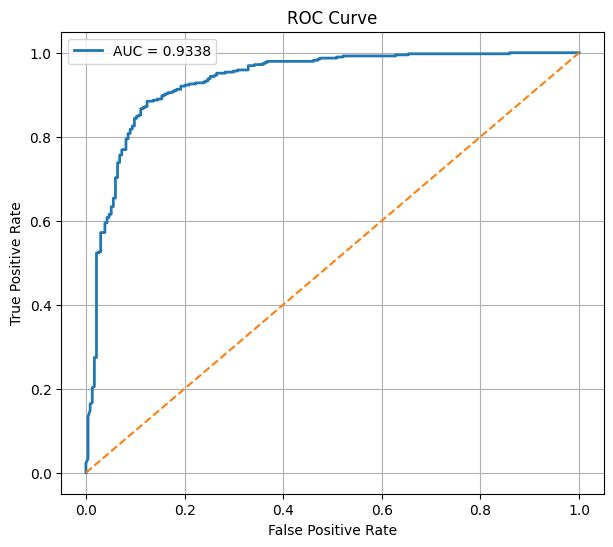

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(

    y_true,

    y_prob

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

Show Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step


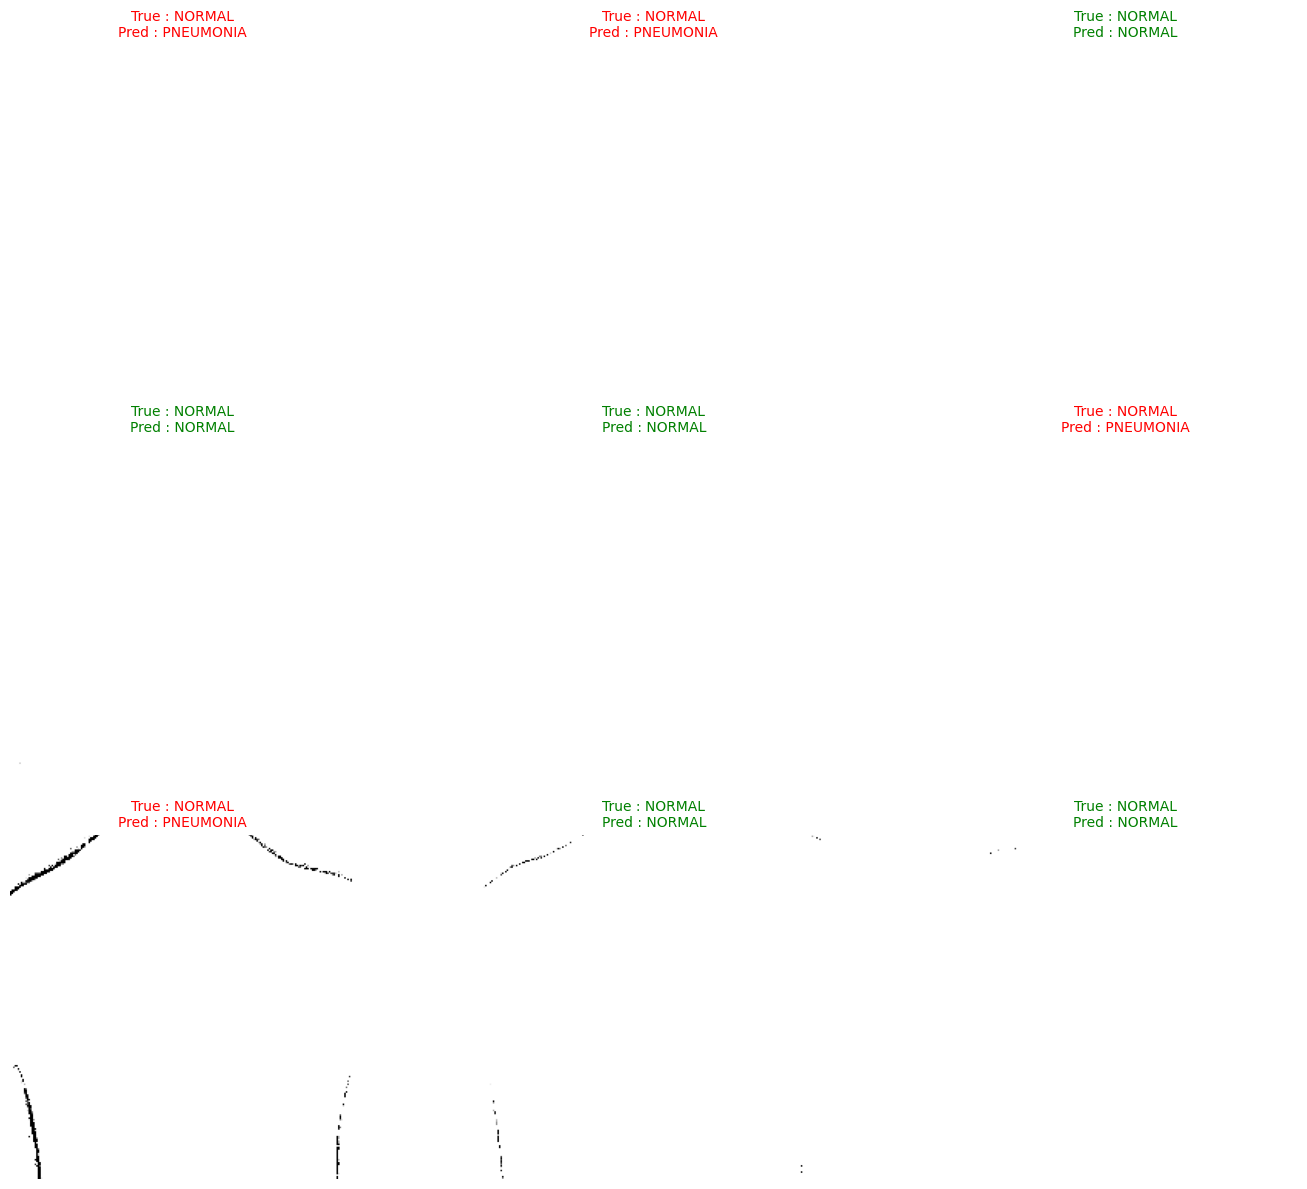

In [ ]:
class_names = ["NORMAL", "PNEUMONIA"]

images, labels = next(iter(test_ds))

predictions = best_model.predict(images)

predictions = (predictions > 0.5).astype(int)

plt.figure(figsize=(15,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

    true_label = class_names[int(labels[i])]

    pred_label = class_names[int(predictions[i])]

    color = "green" if true_label == pred_label else "red"

    plt.title(

        f"True : {true_label}\nPred : {pred_label}",

        color=color,

        fontsize=10

    )

plt.tight_layout()

plt.show()

Save Final Model

In [ ]:
best_model.save("Custom_CNN_Final_Model.keras")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


Final Test Metrics

In [ ]:
loss, accuracy, precision, recall, auc_score = best_model.evaluate(test_ds)

print("="*40)

print(f"Test Accuracy  : {accuracy:.4f}")

print(f"Test Precision : {precision:.4f}")

print(f"Test Recall    : {recall:.4f}")

print(f"Test AUC       : {auc_score:.4f}")

print(f"Test Loss      : {loss:.4f}")

print("="*40)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.8013 - auc: 0.9053 - loss: 0.8393 - precision: 0.7639 - recall: 0.9872
Test Accuracy  : 0.8013
Test Precision : 0.7639
Test Recall    : 0.9872
Test AUC       : 0.9053
Test Loss      : 0.8393


Training Summary

In [ ]:
print("========== TRAINING SUMMARY ==========")

print(f"Epochs Trained : {len(history.history['loss'])}")

print(f"Best Training Accuracy : {max(history.history['accuracy']):.4f}")

print(f"Best Validation Accuracy : {max(history.history['val_accuracy']):.4f}")

print(f"Lowest Validation Loss : {min(history.history['val_loss']):.4f}")

print("======================================")

========== TRAINING SUMMARY ==========
Epochs Trained : 17
Best Training Accuracy : 0.9523
Best Validation Accuracy : 0.9645
Lowest Validation Loss : 0.1067
